In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

### Data Reading

In [11]:
data_path = Path("../data/raw/financial_phrasebank.csv")
data = pd.read_csv (data_path)

### Dataset Overview

In [12]:
data.head()

,sentence,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sentence  2264 non-null   str  
 1   label     2264 non-null   str  
dtypes: str(2)
memory usage: 321.6 KB


In [16]:
data["label"].unique()

<ArrowStringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

In [14]:
data["label"].value_counts()

label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

### Missing Values
- There is no missing values :)

In [18]:
data.isnull().sum()

sentence    0
label       0
dtype: int64

### Duplicate Analysiss
- Detected 5 duplicate samples.

In [19]:
data.duplicated().sum()

np.int64(5)

### Class Distribution
- The dataset is moderately imbalanced, with the Neutral class being dominant.

In [26]:
data["label"].value_counts(normalize=True)*100

label
neutral     61.354582
positive    25.232404
negative    13.413015
Name: proportion, dtype: float64

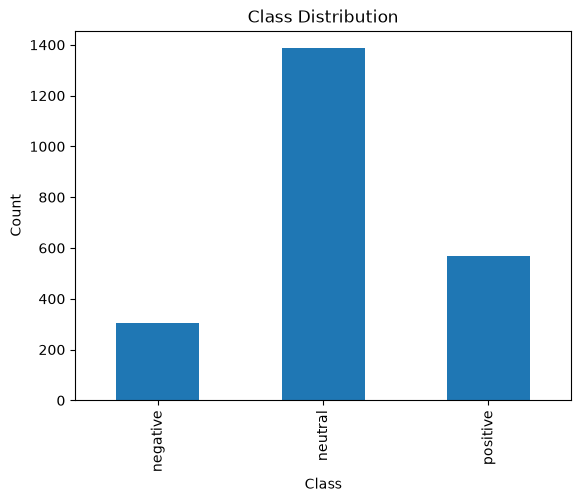

In [28]:
data["label"].value_counts().sort_index().plot(kind="bar")

plt.title ("Class Distribution")
plt.xlabel ("Class")
plt.ylabel ("Count")
plt.show()

### Sentence Length Analysis
- The average sentence length is 22.43 words (min:2, max:81), indicating that most samples are relatively short and suitable for efficient tokenization.

In [33]:
data["sentence_len"] = data["sentence"].apply (lambda x: len(x.split()))
data["sentence_len"].describe()

count    2259.00000
mean       22.43382
std        10.12125
min         2.00000
25%        15.00000
50%        21.00000
75%        28.00000
max        81.00000
Name: sentence_len, dtype: float64

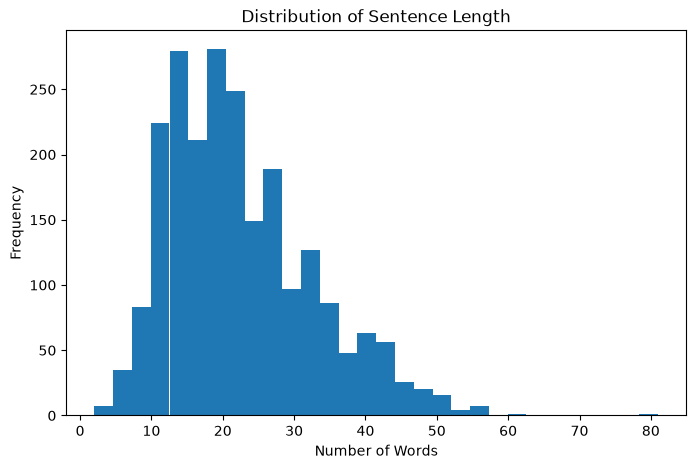

In [ ]:
plt.figure (figsize=(8,5))
plt.hist (data["sentence_len"], bins=30)
plt.title ("Distribution of Sentence Length")
plt.xlabel ("Number of Words")
plt.ylabel ("Frequency")
plt.show()
